# Car fuels — petrol: weekly BVAR-SV-outlier

This notebook estimates the petrol sub-model of the euro-area energy-inflation suite.
The endogenous block contains weekly absolute changes in the WOB petrol pre-tax price,
crude oil and refined petroleum prices. The model uses **24 weekly lags**, stochastic
volatility and model-based transitory outliers.

The weekly calendar is Monday–Sunday and labelled by Monday. Commodity information
aligned to WOB Monday $t$ comes from the preceding completed commodity week, avoiding
post-Monday information. Prices enter the BVAR in absolute differences:

$$
y_t = c + \sum_{\ell=1}^{24} B_\ell y_{t-\ell} + \nu_t,
\qquad
\nu_t=A^{-1}O_t\Lambda_t^{1/2}\varepsilon_t.
$$

## 1. Imports and configuration

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / "src").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "src" / "model",
    PROJECT_ROOT,
    Path.cwd(),
]
for candidate in MODEL_DIR_CANDIDATES:
    required_modules = (
        "energy_bvar_model.py",
        "energy_bvar_weekly_fuels.py",
        "energy_bvar_plot.py",
        "energy_bvar_io.py",
    )
    if all((candidate / name).exists() for name in required_modules):
        sys.path.insert(0, str(candidate))
        MODEL_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Place energy_bvar_model.py, energy_bvar_weekly_fuels.py, "
        "energy_bvar_plot.py and energy_bvar_io.py in src/model/."
    )

from energy_bvar_model import (
    BVARSVOPriorConfig,
    SamplerConfig,
    coefficient_posterior_tables,
    forecast_bvar_sv_outlier,
    forecast_error_variance_decomposition,
    historical_decomposition,
    impulse_responses,
    make_bvar_svo_prior,
    mcmc_diagnostics,
    nowcast_summary_table,
    posterior_outlier_probability,
    posterior_predictive_statistics,
    prepare_bvar_panel,
    residual_diagnostic_table,
    run_energy_bvar,
    stability_diagnostics,
    stationarity_tests,
)
from energy_bvar_io import save_energy_bvar_result
from energy_bvar_weekly_fuels import (
    load_weekly_fuel_panel,
    load_weekly_tax_context,
    reattribute_weekly_taxes,
    weekly_forecast_horizon_table,
    weekly_fuel_series_construction_table,
    weekly_fuel_spec,
    weekly_paths_to_monthly_mean,
)
from energy_bvar_plot import (
    plot_absolute_differences,
    plot_chain_acf_grid,
    plot_coefficient_heatmap,
    plot_data_levels,
    plot_fevd,
    plot_forecast_comparison,
    plot_historical_decomposition,
    plot_impulse_responses,
    plot_minnesota_prior_by_equation,
    plot_nowcast_fan,
    plot_phi_and_outlier_priors,
    plot_posterior_predictive_check,
    plot_short_forecast_fan,
    plot_shrinkage_comparison,
    plot_spectral_radius,
    plot_standardized_residuals,
    plot_trace_grid,
    plot_volatility_decomposition,
    style_numeric_table,
)

pd.set_option("display.max_rows", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 190)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

MODEL = "petrol"
SPEC = weekly_fuel_spec(MODEL)
COMPONENT = "car_fuels_petrol"
SEED = 42
P = 24
VARIABLES = SPEC["variables"]
TARGET = SPEC["target"]
UNITS = SPEC["units"]
SAVE_RESULTS = False
RESULTS_ROOT = PROJECT_ROOT / "results"

# Only used for automated smoke tests. Normal research runs keep the paper setup.
FAST_MODE = os.getenv("ENERGY_BVAR_FAST_TEST", "0") == "1"
FORECAST_H = 8 if FAST_MODE else 26
FORECAST_DRAWS = 10 if FAST_MODE else 500
PPC_DRAWS = 10 if FAST_MODE else 200
STRUCTURAL_DRAWS = 10 if FAST_MODE else 300

print(f"Project root: {PROJECT_ROOT}")
print(f"Model modules: {MODEL_DIR}")
print(f"Model: {SPEC['label']}")
print(f"Fast test mode: {FAST_MODE}")

Project root: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
Model modules: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model
Model: Car fuels — petrol
Fast test mode: False


## 2. Data

Dataset: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260805\car_fuels_weekly.csv
Sample calendar: 2005-01-03 to 2026-08-10
Rows: 1,128; all dates Monday: True


,model_unit,source,construction,weekly_alignment,commodity_shift_weeks
series,,,,,
wob_petrol_pre_tax,"EUR per 1,000 litres",European Commission Weekly Oil Bulletin,"Official pre-tax consumer price, Monday observation",Monday WOB date,—
crude_oil_eur,EUR per barrel,Bloomberg crude oil and EUR/USD,"Daily USD/barrel converted to EUR/barrel, then weekly mean",shift=1 aligns WOB Monday t with the preceding completed Monday-Sunday commodity week; shift=0 aligns it with the same week and therefore includes post-Monday quotations.,1.00
refined_petroleum_eur,EUR per barrel,Bloomberg refined-product future and EUR/USD,"Daily USD/metric-tonne quote converted with 7.44 barrels per tonne and EUR/USD, then weekly mean",shift=1 aligns WOB Monday t with the preceding completed Monday-Sunday commodity week; shift=0 aligns it with the same week and therefore includes post-Monday quotations.,1.00


,wob_petrol_pre_tax,crude_oil_eur,refined_petroleum_eur
date,,,
2026-05-25,1019.75,88.76,1.89
2026-06-01,981.15,79.94,1.66
2026-06-08,956.25,81.79,1.68
2026-06-15,940.29,78.66,1.64
2026-06-22,904.91,69.32,1.45
2026-06-29,899.03,66.19,1.42
2026-07-06,889.08,64.07,1.44
2026-07-13,921.85,66.34,1.57
2026-07-20,966.39,74.34,1.78


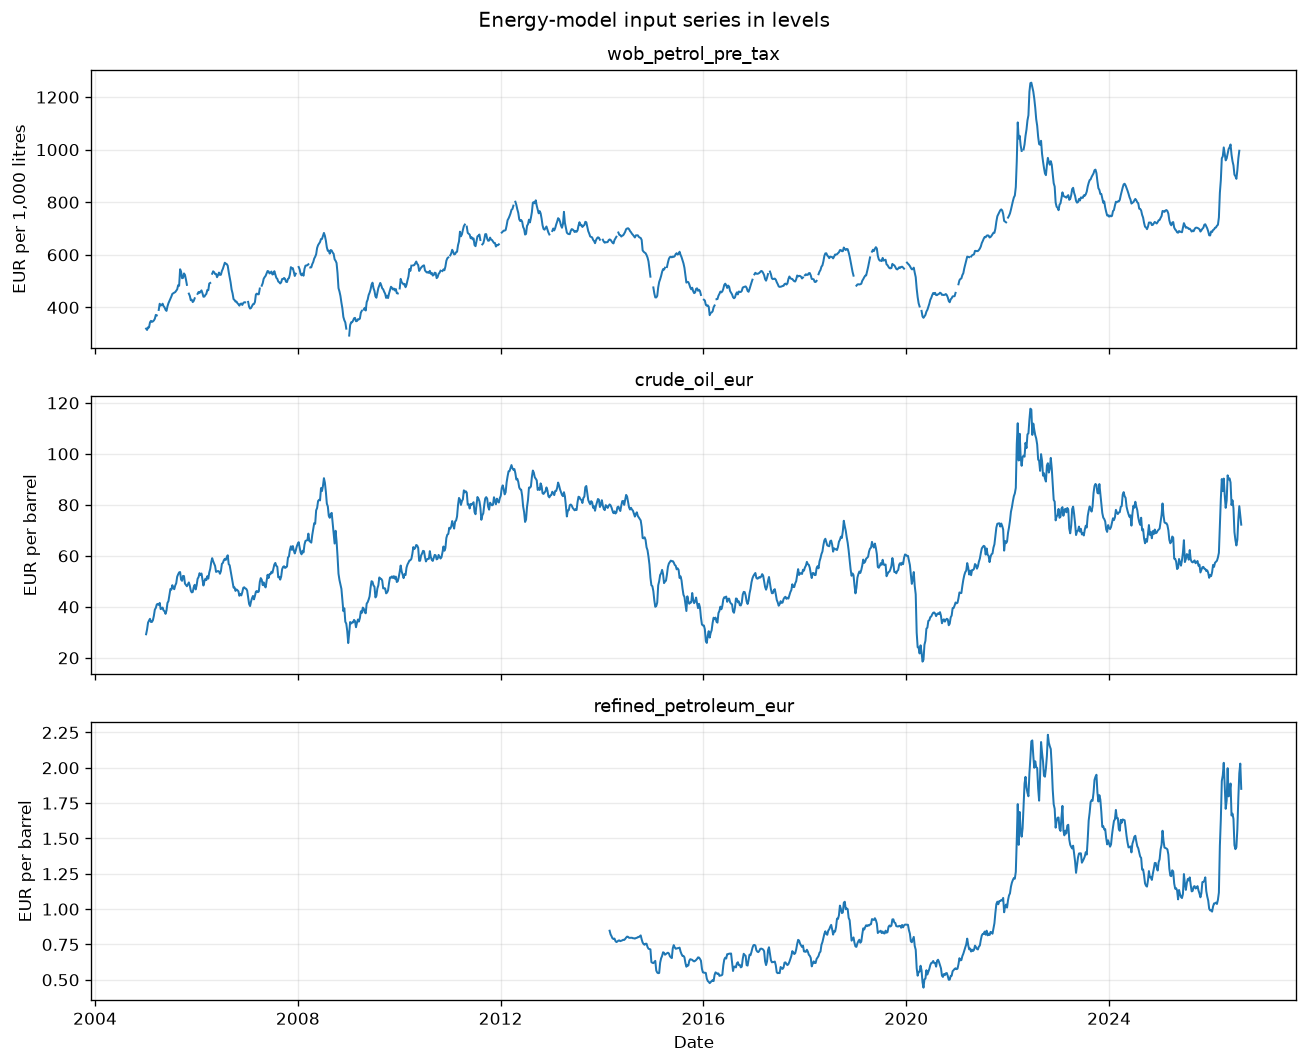

In [2]:
# Set VINTAGE = "YYYYMMDD" to force one processed vintage.
VINTAGE = None
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"

if VINTAGE is None:
    candidates = sorted(
        path
        for path in PROCESSED_ROOT.glob(f"*/{SPEC['dataset']}")
        if path.is_file()
    )
    if not candidates:
        raise FileNotFoundError(
            f"No {SPEC['dataset']} found below {PROCESSED_ROOT}."
        )
    COMPONENT_DATASET = candidates[-1]
else:
    COMPONENT_DATASET = PROCESSED_ROOT / VINTAGE / SPEC["dataset"]

levels = load_weekly_fuel_panel(COMPONENT_DATASET, model=MODEL)

print(f"Dataset: {COMPONENT_DATASET}")
print(f"Sample calendar: {levels.index.min().date()} to {levels.index.max().date()}")
print(f"Rows: {len(levels):,}; all dates Monday: {(levels.index.dayofweek == 0).all()}")

display(style_numeric_table(
    weekly_fuel_series_construction_table(COMPONENT_DATASET, MODEL),
    caption="Construction of the weekly petrol-model level series",
))
display(style_numeric_table(
    levels.tail(12),
    caption="Latest processed weekly levels",
))
plot_data_levels(levels, units=UNITS)
plt.show()

The endogenous vector is ordered from the consumer price upstream through the
commodity chain:

$$
y_t=
\begin{bmatrix}
\Delta P_t^{\mathrm{petrol,pre\ tax}}\\
\Delta P_t^{\mathrm{crude}}\\
\Delta P_t^{\mathrm{refined\ petroleum}}
\end{bmatrix},
\qquad \Delta x_t=x_t-x_{t-1}.
$$

No log transformation and no seasonal dummy are used in this weekly equation.

In [3]:
prep = prepare_bvar_panel(
    levels,
    p=P,
    variables=VARIABLES,
    frequency="weekly",
)

transformation_summary = pd.Series({
    "frequency": prep["frequency"],
    "calendar_rule": prep["calendar_rule"],
    "balanced_change_start": prep["balanced_start"],
    "balanced_change_end": prep["balanced_end"],
    "balanced_changes": prep["n_balanced_changes"],
    "VAR_regression_observations": prep["n_regression_observations"],
    "regression_columns_per_equation": prep["k"],
    "ragged_edge_weeks": prep["n_ragged_periods"],
    "latest_calendar_week": prep["last_calendar_date"],
})
display(style_numeric_table(
    transformation_summary.to_frame("value"),
    caption="Transformation and estimation sample",
))
display(style_numeric_table(
    prep["ragged"],
    caption="Ragged-edge absolute weekly changes",
))
plot_absolute_differences(prep["differences"], units=UNITS)
plt.show()

ValueError: Interior missing observations in the transformed VAR panel at 2014-04-21, 2014-04-28, 2014-12-22, 2014-12-29, 2015-01-05, 2015-04-06, 2015-04-13, 2015-12-21, 2015-12-28, 2016-01-04 ...

## 3. Priors

In [ ]:
prior_config = BVARSVOPriorConfig(
    lambda1=0.20,
    lambda2=0.50,
    lambda3=1.00,
    lambda4=10.0,
    a_prior_var=10.0,
    phi_prior_mean=0.02,
    phi_prior_df=10.0,
    h0_var=4.0,
    outlier_mean_frequency=1.0 / 48.0,
    outlier_prior_observations=120.0,
    outlier_grid_min=2.0,
    outlier_grid_max=20.0,
    outlier_grid_step=1.0,
    ksc_offset_scale=1e-6,
)
prior = make_bvar_svo_prior(prep, prior_config)

prior_table = pd.DataFrame({
    "value": [
        prior_config.lambda1,
        prior_config.lambda2,
        prior_config.lambda3,
        prior_config.lambda4,
        prior_config.a_prior_var,
        prior_config.phi_prior_mean,
        prior["outlier_alpha"],
        prior["outlier_beta"],
    ],
    "interpretation": [
        "overall Minnesota lag tightness",
        "additional cross-lag tightness",
        "lag-decay exponent",
        "constant prior scale",
        "variance of each free contemporaneous A coefficient",
        "prior mean of volatility-of-volatility variance",
        "Beta outlier pseudo-count",
        "Beta regular-observation pseudo-count",
    ],
}, index=[
    "lambda1", "lambda2", "lambda3", "lambda4",
    "A prior variance", "phi prior mean",
    "outlier alpha", "outlier beta",
])
display(style_numeric_table(prior_table, caption="Prior hyperparameters"))

prior_figures = plot_minnesota_prior_by_equation(prior, VARIABLES, P)
for equation, figure in prior_figures.items():
    display(figure)
    plt.close(figure)
plot_phi_and_outlier_priors(prior)
plt.show()

## 4. Posterior and Gibbs sampler

In [ ]:
sampler_config = SamplerConfig(
    reps=40 if FAST_MODE else 6_000,
    burn=20 if FAST_MODE else 3_000,
    thin=1,
    seed=SEED,
    max_stability_tries=1_000,
    progress_every=0 if FAST_MODE else 500,
)

result = run_energy_bvar(
    levels=levels,
    model_id=COMPONENT,
    vintage=COMPONENT_DATASET.parent.name,
    p=P,
    variables=VARIABLES,
    frequency="weekly",
    prior_config=prior_config,
    sampler_config=sampler_config,
    code_version="energy_bvar-weekly-v1",
)

print(f"Retained posterior draws: {result['n_draws']:,}")
print(f"Run ID: {result['metadata']['run_id']}")
print(f"Frequency: {result['metadata']['frequency']}")
print(
    "B instability proposal rejection rate: "
    f"{result['B_instability_rejection_rate']:.2%}"
)
display(style_numeric_table(
    pd.Series(dict(zip(VARIABLES, result["ksc_offsets"]))).to_frame("KSC offset"),
    caption="Adaptive KSC offsets",
))

if SAVE_RESULTS:
    saved_result_paths = save_energy_bvar_result(result, RESULTS_ROOT)
    print(f"Saved run: {saved_result_paths['directory']}")

## 5. Posterior results

In [ ]:
coefficient_tables = coefficient_posterior_tables(result)
for equation in VARIABLES:
    print()
    print(f"{equation} equation")
    display(style_numeric_table(
        coefficient_tables[equation],
        caption=f"Posterior coefficients — {equation} equation",
    ))
    plot_coefficient_heatmap(result, equation=equation)
    plot_shrinkage_comparison(result, equations=[equation])
    plt.show()

In [ ]:
display(style_numeric_table(
    mcmc_diagnostics(result),
    caption="MCMC diagnostics",
))
display(style_numeric_table(
    stability_diagnostics(result).to_frame("value"),
    caption="VAR stability diagnostics",
))
plot_trace_grid(result)
plt.show()
plot_chain_acf_grid(result, nlags=60)
plt.show()
plot_spectral_radius(result)
plt.show()

In [ ]:
outlier_probability = posterior_outlier_probability(result)
display(style_numeric_table(
    outlier_probability.sort_values(TARGET, ascending=False).head(15),
    caption="Largest posterior outlier probabilities",
))
plot_volatility_decomposition(result)
plt.show()

display(style_numeric_table(
    residual_diagnostic_table(result),
    caption="Standardized structural-residual diagnostics",
))
plot_standardized_residuals(result)
plt.show()

In [ ]:
ppc_summary, ppc_draws = posterior_predictive_statistics(
    result,
    n_draws=PPC_DRAWS,
    seed=456,
)
display(style_numeric_table(
    ppc_summary,
    caption="Posterior predictive checks",
))
for equation in VARIABLES:
    plot_posterior_predictive_check(ppc_summary, equation=equation)
    plt.show()

display(style_numeric_table(
    stationarity_tests(prep["balanced"]),
    caption="Stationarity tests on balanced weekly changes",
))

## 6. Ragged-edge nowcast and weekly forecast

In [ ]:
forecast_unconditional = forecast_bvar_sv_outlier(
    result,
    H=FORECAST_H,
    n_draws=FORECAST_DRAWS,
    seed=123,
)

display(style_numeric_table(
    nowcast_summary_table(
        forecast_unconditional,
        observed_levels=levels,
        variable=TARGET,
        missing_only=True,
    ),
    caption="Ragged-edge petrol nowcast",
))
display(style_numeric_table(
    weekly_forecast_horizon_table(
        forecast_unconditional,
        TARGET,
        horizons=(1, 4, 13, 26),
    ),
    caption="Weekly petrol pre-tax forecast",
))

plot_nowcast_fan(
    forecast_unconditional,
    levels,
    TARGET,
    last_obs=52,
    ylabel=UNITS[TARGET],
)
plt.show()
plot_short_forecast_fan(
    forecast_unconditional,
    levels,
    TARGET,
    last_obs=78,
    ylabel=UNITS[TARGET],
)
plt.show()

## 7. Conditional commodity-price scenarios

In [ ]:
last_crude = float(levels["crude_oil_eur"].dropna().iloc[-1])
last_refined = float(levels["refined_petroleum_eur"].dropna().iloc[-1])
crude_up_10 = np.full(FORECAST_H, 1.10 * last_crude)
refined_up_10 = np.full(FORECAST_H, 1.10 * last_refined)

forecast_crude_up_10 = forecast_bvar_sv_outlier(
    result,
    H=FORECAST_H,
    level_conditions={"crude_oil_eur": crude_up_10},
    n_draws=FORECAST_DRAWS,
    seed=123,
)
forecast_refined_up_10 = forecast_bvar_sv_outlier(
    result,
    H=FORECAST_H,
    level_conditions={"refined_petroleum_eur": refined_up_10},
    n_draws=FORECAST_DRAWS,
    seed=123,
)

plot_forecast_comparison(
    forecast_unconditional,
    forecast_crude_up_10,
    levels,
    TARGET,
    last_obs=78,
    title="Petrol pre-tax price — unconditional versus crude oil +10%",
    ylabel=UNITS[TARGET],
)
plt.show()
plot_forecast_comparison(
    forecast_unconditional,
    forecast_refined_up_10,
    levels,
    TARGET,
    last_obs=78,
    title="Petrol pre-tax price — unconditional versus refined petroleum +10%",
    ylabel=UNITS[TARGET],
)
plt.show()

## 8. Ex-post tax re-attribution

The BVAR forecasts the pre-tax WOB price. Excise and VAT are re-attributed after
forecasting under the paper's random-walk assumption:

$$
P_t^{\mathrm{after\ tax}}
=\left(P_t^{\mathrm{pre\ tax}}+\mathrm{excise}_t\right)
\left(1+\frac{\mathrm{VAT}_t}{100}\right).
$$

The resulting weekly prices are then averaged within calendar months. Petrol and
diesel are combined only after both sub-models have been estimated.

In [ ]:
try:
    tax_context = load_weekly_tax_context(COMPONENT_DATASET, model=MODEL)
    taxed_forecast = reattribute_weekly_taxes(
        forecast_unconditional,
        tax_context,
    )
    monthly_after_tax_paths, monthly_after_tax_dates = weekly_paths_to_monthly_mean(
        taxed_forecast["after_tax_paths"],
        taxed_forecast["path_dates"],
    )

    tax_summary = pd.Series({
        "WOB source": str(tax_context["wob_path"]),
        "WOB prefix": tax_context["wob_prefix"],
        "maximum historical tax-identity error": tax_context["max_tax_identity_error"],
        "forecast excise": taxed_forecast["excise"][-1],
        "forecast VAT percent": taxed_forecast["vat_percent"][-1],
        "tax assumption": taxed_forecast["tax_assumption"],
    })
    display(style_numeric_table(
        tax_summary.to_frame("value"),
        caption="Tax re-attribution inputs",
    ))

    monthly_q = np.percentile(
        monthly_after_tax_paths,
        [5, 16, 50, 84, 95],
        axis=0,
    )
    monthly_after_tax_table = pd.DataFrame({
        "q05": monthly_q[0],
        "q16": monthly_q[1],
        "median": monthly_q[2],
        "q84": monthly_q[3],
        "q95": monthly_q[4],
    }, index=monthly_after_tax_dates)
    display(style_numeric_table(
        monthly_after_tax_table,
        caption="Monthly mean petrol price after tax",
    ))

    fig, ax = plt.subplots(figsize=(10.5, 4.4))
    ax.fill_between(
        monthly_after_tax_dates,
        monthly_q[0],
        monthly_q[4],
        alpha=0.20,
        label="90% interval",
    )
    ax.fill_between(
        monthly_after_tax_dates,
        monthly_q[1],
        monthly_q[3],
        alpha=0.35,
        label="68% interval",
    )
    ax.plot(monthly_after_tax_dates, monthly_q[2], linewidth=1.8, label="Median")
    ax.set_title("Monthly mean petrol consumer price after tax")
    ax.set_ylabel("EUR per 1,000 litres")
    ax.grid(alpha=0.22)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()
except (FileNotFoundError, KeyError, ValueError) as error:
    tax_context = None
    taxed_forecast = None
    print("Tax re-attribution was not run:")
    print(error)
    print("The BVAR forecast itself is unaffected; restore the WOB source path or pass it explicitly.")

## 9. Structural analysis

In [ ]:
# Structural objects can be large. Use a reproducible posterior subset for plots.
structural_count = min(STRUCTURAL_DRAWS, result["n_draws"])
structural_index = np.linspace(
    0,
    result["n_draws"] - 1,
    structural_count,
    dtype=int,
)
structural_result = dict(result)
for key in (
    "B", "A", "log_variance", "phi", "outlier_scales",
    "outlier_indicators", "outlier_probabilities",
    "posterior_outlier_probability_draws", "spectral_radius", "log_likelihood",
):
    if key in result:
        structural_result[key] = np.asarray(result[key])[structural_index]
structural_result["n_draws"] = structural_count

irf = impulse_responses(
    structural_result,
    identification="recursive",
    horizon=24,
    shock_unit="structural_std",
)
plot_impulse_responses(irf, cumulative=True, units=UNITS)
plt.show()

fevd = forecast_error_variance_decomposition(
    structural_result,
    identification="recursive",
    horizon=24,
)
plot_fevd(fevd, responses=[TARGET])
plt.show()

hd = historical_decomposition(
    structural_result,
    identification="recursive",
    split_outlier_amplification=True,
)
print(f"Maximum historical-decomposition reconstruction error: {hd['max_reconstruction_error']:.3e}")
plot_historical_decomposition(
    hd,
    response=TARGET,
    last_obs=156,
    unit=UNITS[TARGET],
)
plt.show()

## 10. Forecast validation tests

In [ ]:
base_level = np.asarray(result["prep"]["level_at_balanced_end"], dtype=float)
reconstructed_levels = (
    base_level[None, None, :]
    + np.cumsum(forecast_unconditional["diff_paths"], axis=1)
)
cumulative_error = float(np.max(np.abs(
    reconstructed_levels - forecast_unconditional["level_paths"]
)))

observed = levels.reindex(
    forecast_unconditional["path_dates"]
).to_numpy(dtype=float)
observation_errors = []
for j, variable in enumerate(VARIABLES):
    mask = np.isfinite(observed[:, j])
    if mask.any():
        observation_errors.append(float(np.max(np.abs(
            forecast_unconditional["level_paths"][:, mask, j]
            - observed[None, mask, j]
        ))))
observed_error = max(observation_errors, default=0.0)

crude_condition_error = float(np.max(np.abs(
    forecast_crude_up_10["future_level_paths"][:, :, VARIABLES.index("crude_oil_eur")]
    - crude_up_10[None, :]
)))
refined_condition_error = float(np.max(np.abs(
    forecast_refined_up_10["future_level_paths"][:, :, VARIABLES.index("refined_petroleum_eur")]
    - refined_up_10[None, :]
)))

validation = pd.Series({
    "metadata frequency is weekly": result["metadata"]["frequency"] == "weekly",
    "all processed dates are Mondays": bool((levels.index.dayofweek == 0).all()),
    "all future dates are Mondays": bool((forecast_unconditional["future_dates"].dayofweek == 0).all()),
    "cumulative level identity error": cumulative_error,
    "maximum released-level error": observed_error,
    "crude +10% condition error": crude_condition_error,
    "refined +10% condition error": refined_condition_error,
    "retained unstable share": float(stability_diagnostics(result)["retained_unstable_share"]),
})
display(style_numeric_table(
    validation.to_frame("value"),
    caption="Weekly forecast validation",
))

assert result["metadata"]["frequency"] == "weekly"
assert (levels.index.dayofweek == 0).all()
assert (forecast_unconditional["future_dates"].dayofweek == 0).all()
assert cumulative_error < 1e-8
assert observed_error < 1e-8
assert crude_condition_error < 1e-8
assert refined_condition_error < 1e-8
assert stability_diagnostics(result)["retained_unstable_share"] == 0.0

print("All weekly calendar, ragged-edge and conditioning checks passed.")